# Phase 3: Joint Path Simulation

Run the 6-factor correlated stochastic simulation. This notebook is generated from `bess_valuation_full.ipynb` Phase 3 and can be run independently after Phase 2 has saved calibrated parameter files.


In [1]:
import sys, os
from pathlib import Path

# Resolve project root by searching upward for src/ and data/.
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise RuntimeError('Could not find project root containing src/ and data/.')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.config import SCHWARTZ_SMITH
from src.processes.simulate import (
    JOINT_CORR, _cholesky_joint,
    default_params_from_config, simulate,
    validate_marginals, print_validation_report,
    PathBundle,
)
from src.processes.schwartz_smith import SSParams
from src.processes.hpfc import HPFCParams
from src.processes.imbalance import ImbalanceParams
from src.processes.ancillary import AncillaryParams

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

SEED      = 42
N_PATHS   = 5_000    # reduce to 1000 for fast iteration
N_STEPS   = 17_520   # 1 year at half-hourly resolution
DT        = 1 / (365 * 48)

print(f'Project root: {PROJECT_ROOT}')
print(f'Processed data dir: {PROCESSED}')
print(f'Paths: {N_PATHS:,}   Steps: {N_STEPS:,}   dt: {DT:.6f} yr')
print(f'Horizon: {N_STEPS * DT * 365:.1f} days')


Project root: g:\My Drive\Research\bess_project
Processed data dir: g:\My Drive\Research\bess_project\data\processed
Paths: 5,000   Steps: 17,520   dt: 0.000057 yr
Horizon: 365.0 days


## 1  Load or derive calibrated parameters

In [2]:
def _try_load(cls, *fnames):
    """Load the first available JSON param file, else return None."""
    for fname in fnames:
        p = PROCESSED / fname
        if p.exists():
            print(f'  Loaded: {fname}')
            return cls.from_json(p)
    print(f'  Not found (using config default): {" or ".join(fnames)}')
    return None

ss_cal   = _try_load(SSParams,        'ss_params.json')
hpfc_cal = _try_load(HPFCParams,      'pca_params.json', 'hpfc_params.json')
imb_cal  = _try_load(ImbalanceParams, 'imbalance_params.json')
anc_cal  = _try_load(AncillaryParams, 'ancillary_params.json')

# Fall back to config defaults for any missing.
ss_def, hpfc_def, imb_def, anc_def = default_params_from_config()
ss_p   = ss_cal   if ss_cal   is not None else ss_def
hpfc_p = hpfc_cal if hpfc_cal is not None else hpfc_def
imb_p  = imb_cal  if imb_cal  is not None else imb_def
anc_p  = anc_cal  if anc_cal  is not None else anc_def

print(f'\nSS:    kappa={ss_p.kappa:.3f}, sigma_chi={ss_p.sigma_chi:.3f}, sigma_xi={ss_p.sigma_xi:.3f}')
print(f'HPFC:  K={hpfc_p.n_factors}, alpha={[round(a,3) for a in hpfc_p.alpha]}')
print(f'Imb:   theta={imb_p.theta_delta:.2f}, sigma={imb_p.sigma_delta:.1f}, lambda_j={imb_p.lambda_jump:.4f}')
print(f'Anc:   gamma={anc_p.gamma:.2f}, fleet={anc_p.fleet_mw:.0f} MW')


  Loaded: ss_params.json
  Loaded: pca_params.json
  Loaded: imbalance_params.json
  Loaded: ancillary_params.json

SS:    kappa=2.000, sigma_chi=0.348, sigma_xi=0.123
HPFC:  K=3, alpha=[1.084, 3.4, 2.284]
Imb:   theta=0.83, sigma=18.6, lambda_j=0.0429
Anc:   gamma=2.10, fleet=6500 MW


## 2  Joint correlation matrix — Cholesky decomposition

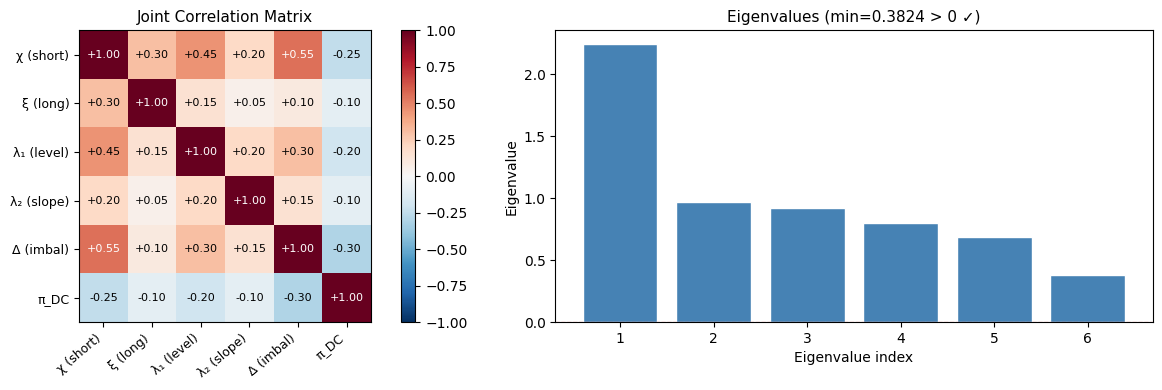

Reconstruction error: 1.11e-16


In [3]:
L = _cholesky_joint()
labels = ['χ (short)', 'ξ (long)', 'λ₁ (level)', 'λ₂ (slope)', 'Δ (imbal)', 'π_DC']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: correlation matrix heatmap
im = axes[0].imshow(JOINT_CORR, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(6)); axes[0].set_yticks(range(6))
axes[0].set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
axes[0].set_yticklabels(labels, fontsize=9)
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, f'{JOINT_CORR[i,j]:+.2f}',
                     ha='center', va='center', fontsize=8,
                     color='white' if abs(JOINT_CORR[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Joint Correlation Matrix', fontsize=11)

# Right: eigenvalue spectrum
eigvals = np.sort(np.linalg.eigvalsh(JOINT_CORR))[::-1]
axes[1].bar(range(1, 7), eigvals, color='steelblue', edgecolor='white')
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Eigenvalue index'); axes[1].set_ylabel('Eigenvalue')
axes[1].set_title(f'Eigenvalues (min={eigvals.min():.4f} > 0 ✓)', fontsize=11)
axes[1].set_xticks(range(1, 7))

plt.tight_layout()
plt.savefig(PROCESSED / 'sim_corr_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Reconstruction error: {np.abs(L @ L.T - JOINT_CORR).max():.2e}')

## 3  Run joint simulation

In [4]:
import time
t0 = time.time()
xi_0 = np.full(N_PATHS, np.log(SCHWARTZ_SMITH['forward_anchor_gbp_mwh']))
bundle = simulate(ss_p, hpfc_p, imb_p, anc_p,
                  n_paths=N_PATHS, n_steps=N_STEPS,
                  dt=DT, seed=SEED, xi_0=xi_0)
elapsed = time.time() - t0

total_mb = (bundle.chi.nbytes + bundle.xi.nbytes + bundle.lam.nbytes +
            bundle.delta_imb.nbytes +
            sum(v.nbytes for v in bundle.pi.values())) / 1e6

print(f'Simulation complete in {elapsed:.1f}s')
print(f'Paths: {bundle.n_paths:,}   Steps: {bundle.n_steps:,}')
print(f'Memory footprint: {total_mb:.0f} MB')
print()
spot_prices = np.exp(bundle.ln_P_base)
print(f'Spot price (P5/P50/P95): '
      f'{np.percentile(spot_prices[:,-1], 5):.1f} / '
      f'{np.percentile(spot_prices[:,-1], 50):.1f} / '
      f'{np.percentile(spot_prices[:,-1], 95):.1f}  GBP/MWh')
print(f'Delta imbalance (P5/P50/P95): '
      f'{np.percentile(bundle.delta_imb[:,-1], 5):.1f} / '
      f'{np.percentile(bundle.delta_imb[:,-1], 50):.1f} / '
      f'{np.percentile(bundle.delta_imb[:,-1], 95):.1f}  GBP/MWh')
print(f'DC_Low clearing (P5/P50/P95): '
      f'{np.percentile(bundle.pi["DC_Low"][:,-1], 5):.2f} / '
      f'{np.percentile(bundle.pi["DC_Low"][:,-1], 50):.2f} / '
      f'{np.percentile(bundle.pi["DC_Low"][:,-1], 95):.2f}  GBP/MW/h')


Simulation complete in 53.1s
Paths: 5,000   Steps: 17,520
Memory footprint: 4906 MB

Spot price (P5/P50/P95): 0.7 / 1.0 / 1.5  GBP/MWh
Delta imbalance (P5/P50/P95): -237.4 / -22.6 / 219.4  GBP/MWh
DC_Low clearing (P5/P50/P95): 1.15 / 5.15 / 9.50  GBP/MW/h


## 4  Sample path visualisation — all state variables

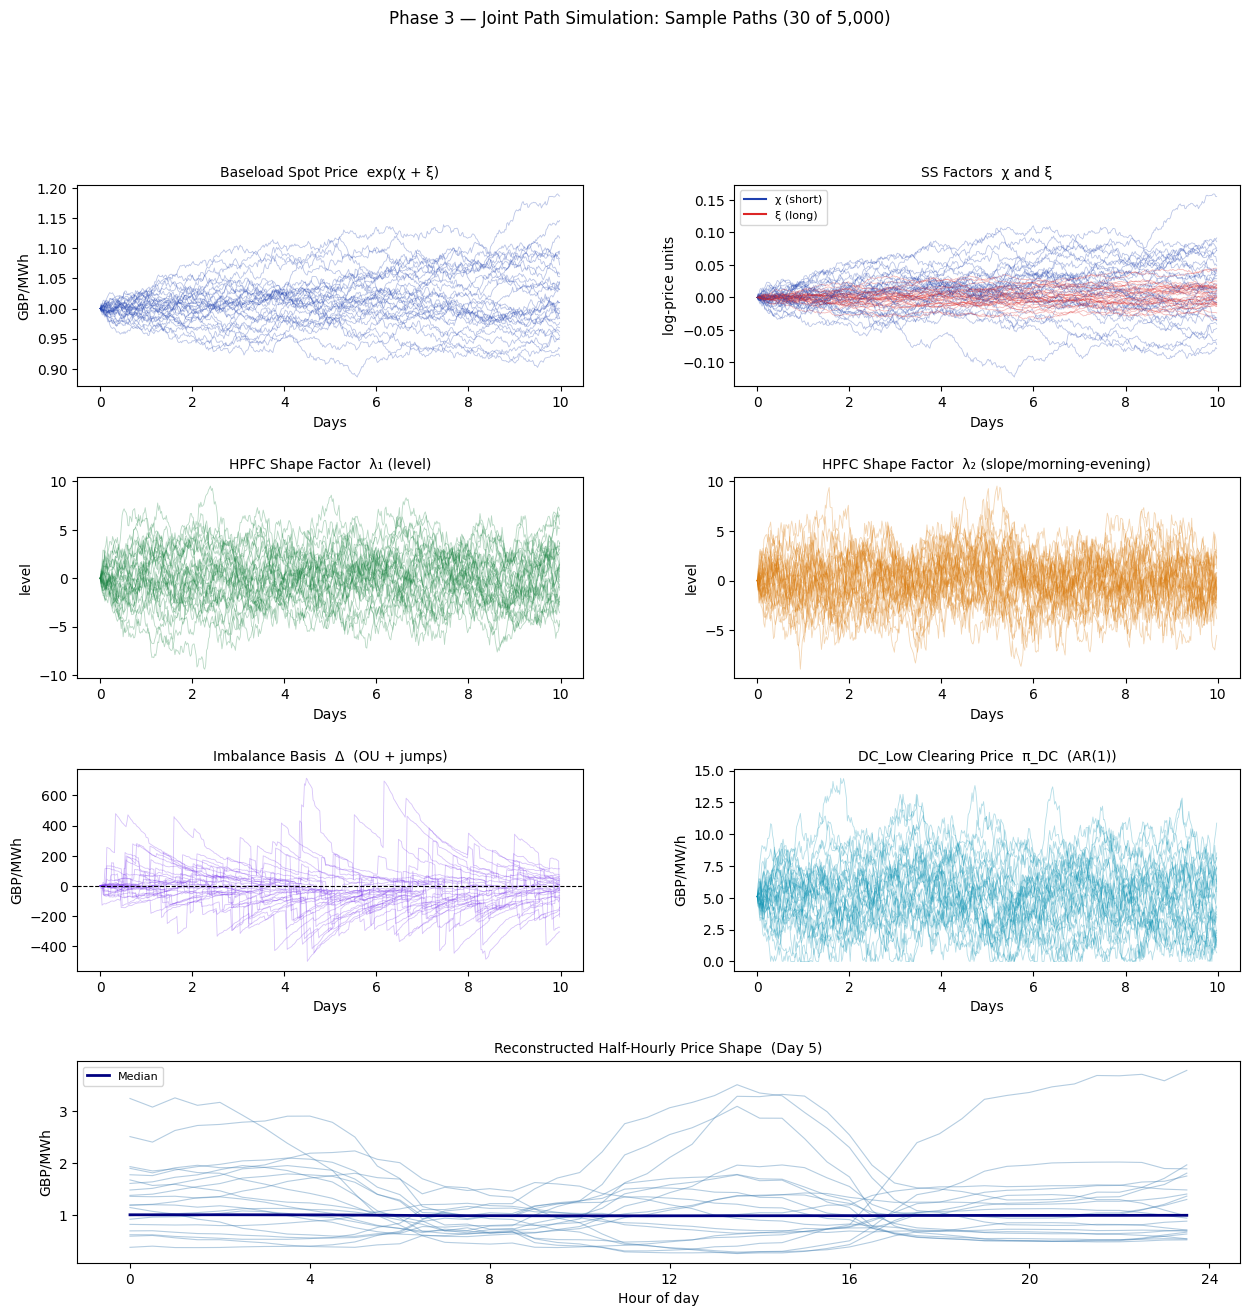

In [5]:
N_SHOW   = 30
t_axis   = np.arange(N_STEPS + 1) * DT * 365   # days
t_show   = t_axis[:480]   # first 10 days
ALPHA    = 0.3
COLORS   = ['#1E40AF', '#DC2626', '#15803D', '#D97706', '#7C3AED', '#0891B2']

fig = plt.figure(figsize=(15, 14))
gs  = gridspec.GridSpec(4, 2, hspace=0.45, wspace=0.3)

# 1. Baseload spot price
ax1 = fig.add_subplot(gs[0, 0])
for i in range(N_SHOW):
    ax1.plot(t_show, np.exp(bundle.ln_P_base[i, :480]),
             color=COLORS[0], alpha=ALPHA, linewidth=0.6)
ax1.set_title('Baseload Spot Price  exp(χ + ξ)', fontsize=10)
ax1.set_ylabel('GBP/MWh'); ax1.set_xlabel('Days')

# 2. SS factors chi and xi
ax2 = fig.add_subplot(gs[0, 1])
for i in range(N_SHOW):
    ax2.plot(t_show, bundle.chi[i, :480], color=COLORS[0], alpha=ALPHA, linewidth=0.6)
    ax2.plot(t_show, bundle.xi[i, :480],  color=COLORS[1], alpha=ALPHA, linewidth=0.6)
ax2.plot([], [], color=COLORS[0], label='χ (short)')
ax2.plot([], [], color=COLORS[1], label='ξ (long)')
ax2.legend(fontsize=8); ax2.set_title('SS Factors  χ and ξ', fontsize=10)
ax2.set_ylabel('log-price units'); ax2.set_xlabel('Days')

# 3. HPFC shape factor lambda_1 (level)
ax3 = fig.add_subplot(gs[1, 0])
for i in range(N_SHOW):
    ax3.plot(t_show, bundle.lam[i, :480, 0], color=COLORS[2], alpha=ALPHA, linewidth=0.6)
ax3.set_title('HPFC Shape Factor  λ₁ (level)', fontsize=10)
ax3.set_ylabel('level'); ax3.set_xlabel('Days')

# 4. HPFC shape factor lambda_2 (slope)
ax4 = fig.add_subplot(gs[1, 1])
for i in range(N_SHOW):
    ax4.plot(t_show, bundle.lam[i, :480, 1], color=COLORS[3], alpha=ALPHA, linewidth=0.6)
ax4.set_title('HPFC Shape Factor  λ₂ (slope/morning-evening)', fontsize=10)
ax4.set_ylabel('level'); ax4.set_xlabel('Days')

# 5. Imbalance basis delta
ax5 = fig.add_subplot(gs[2, 0])
for i in range(N_SHOW):
    ax5.plot(t_show, bundle.delta_imb[i, :480], color=COLORS[4], alpha=ALPHA, linewidth=0.6)
ax5.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax5.set_title('Imbalance Basis  Δ  (OU + jumps)', fontsize=10)
ax5.set_ylabel('GBP/MWh'); ax5.set_xlabel('Days')

# 6. DC_Low ancillary clearing
ax6 = fig.add_subplot(gs[2, 1])
for i in range(N_SHOW):
    ax6.plot(t_show, bundle.pi['DC_Low'][i, :480], color=COLORS[5], alpha=ALPHA, linewidth=0.6)
ax6.set_title('DC_Low Clearing Price  π_DC  (AR(1))', fontsize=10)
ax6.set_ylabel('GBP/MW/h'); ax6.set_xlabel('Days')

# 7. Reconstructed half-hourly price shape for one random day
ax7 = fig.add_subplot(gs[3, :])
phi = np.array(hpfc_p.loadings)   # (K, 48)
day_step = 48 * 5   # step index for day 5
hh_axis = np.arange(48) * 0.5     # hours
# 20 random paths on day 5
idx = np.random.default_rng(99).integers(0, N_PATHS, 20)
for i in idx:
    lam_t = bundle.lam[i, day_step, :]           # (K,)
    shape  = phi.T @ lam_t                        # (48,)
    ln_price_hh = bundle.ln_P_base[i, day_step] + shape
    ax7.plot(hh_axis, np.exp(ln_price_hh), color='steelblue', alpha=0.4, linewidth=0.8)
# Median
med_lam = np.median(bundle.lam[:, day_step, :], axis=0)
med_base = np.median(bundle.ln_P_base[:, day_step])
shape_med = phi.T @ med_lam
ax7.plot(hh_axis, np.exp(med_base + shape_med), color='navy', linewidth=2, label='Median')
ax7.set_title('Reconstructed Half-Hourly Price Shape  (Day 5)', fontsize=10)
ax7.set_xlabel('Hour of day'); ax7.set_ylabel('GBP/MWh')
ax7.set_xticks(range(0, 25, 4))
ax7.legend(fontsize=8)

plt.suptitle('Phase 3 — Joint Path Simulation: Sample Paths (30 of 5,000)', fontsize=12, y=1.005)
plt.savefig(PROCESSED / 'sim_sample_paths.png', dpi=120, bbox_inches='tight')
plt.show()

## 5  Marginal validation — simulated vs theoretical moments


── Marginal Validation Report ─────────────────────────────────
  ✓  chi_variance                         sim=+0.0296  exp=+0.0297
  ✓  xi_mean                              sim=+0.0047  exp=+0.0037
  ✓  xi_variance                          sim=+0.0154  exp=+0.0151
  ✓  delta_stationary_mean                sim=-16.6987  exp=-20.3607
  ✓  pi_dc_non_negative                   sim=+0.0000  exp=+0.0000
  ✓  pi_dc_bounded                        sim=+20.0471  exp=+500.0000
  ✓  cross_corr_chi_delta_increment       sim=+0.0566  exp=+0.0568
────────────────────────────────────────────────────────────────
  All checks passed.



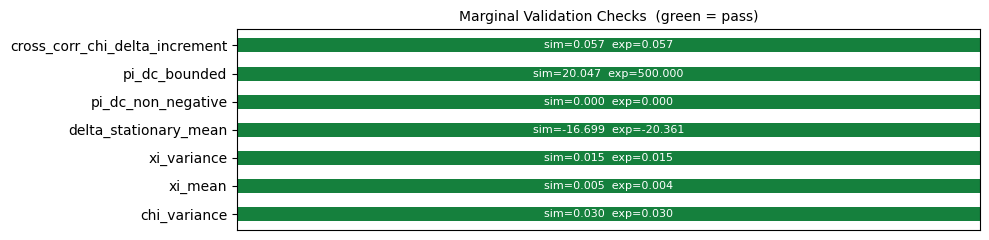

In [6]:
results = validate_marginals(bundle, ss_p, imb_params=imb_p, dt=DT)
print_validation_report(results)

# Summary bar chart
names  = list(results.keys())
passed = [r[0] for r in results.values()]
colors = ['#15803D' if p else '#DC2626' for p in passed]

fig, ax = plt.subplots(figsize=(10, 2.5))
bars = ax.barh(names, [1]*len(names), color=colors, height=0.5)
for bar, (ok, sim, exp) in zip(bars, results.values()):
    label = f'sim={sim:.3f}  exp={exp:.3f}'
    ax.text(0.5, bar.get_y() + bar.get_height()/2, label,
            ha='center', va='center', fontsize=8, color='white')
ax.set_xlim(0, 1); ax.set_xticks([])
ax.set_title('Marginal Validation Checks  (green = pass)', fontsize=10)
plt.tight_layout()
plt.savefig(PROCESSED / 'sim_validation.png', dpi=120, bbox_inches='tight')
plt.show()

## 6  Cross-correlation check — simulated vs JOINT_CORR spec

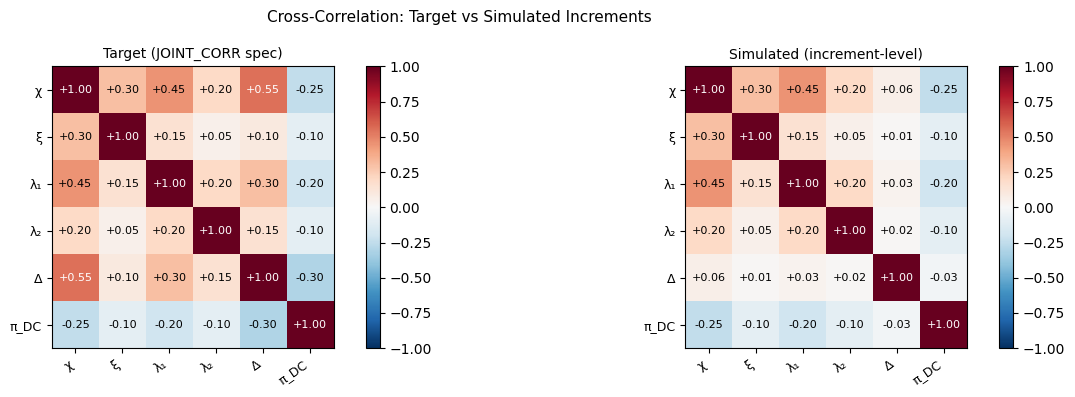

Max |sim - target| correlation error: 0.492
Note: delta and pi_DC errors are inflated by jump noise in delta increments.


In [7]:
# Build a (N_paths, 6) matrix of half-step increments at mid-horizon
mid   = N_STEPS // 2
dchi  = np.diff(bundle.chi[:,  mid:mid+200], axis=1).ravel()
dxi   = np.diff(bundle.xi[:,   mid:mid+200], axis=1).ravel()
dlam1 = np.diff(bundle.lam[:, mid:mid+200, 0], axis=1).ravel()
dlam2 = np.diff(bundle.lam[:, mid:mid+200, 1], axis=1).ravel()
ddelt = np.diff(bundle.delta_imb[:, mid:mid+200], axis=1).ravel()
dpidc = np.diff(bundle.pi['DC_Low'][:, mid:mid+200], axis=1).ravel()

inc_mat = np.column_stack([dchi, dxi, dlam1, dlam2, ddelt, dpidc])
sim_corr = np.corrcoef(inc_mat.T)

labels6 = ['χ', 'ξ', 'λ₁', 'λ₂', 'Δ', 'π_DC']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mat, title in zip(axes,
                           [JOINT_CORR, sim_corr],
                           ['Target (JOINT_CORR spec)', 'Simulated (increment-level)']):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels(labels6, rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(labels6, fontsize=9)
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f'{mat[i,j]:+.2f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(mat[i,j]) > 0.5 else 'black')
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=10)
plt.suptitle('Cross-Correlation: Target vs Simulated Increments', fontsize=11)
plt.tight_layout()
plt.savefig(PROCESSED / 'sim_cross_corr.png', dpi=120, bbox_inches='tight')
plt.show()

max_err = np.abs(sim_corr - JOINT_CORR).max()
print(f'Max |sim - target| correlation error: {max_err:.3f}')
print('Note: delta and pi_DC errors are inflated by jump noise in delta increments.')

## 7  Year-over-year chaining — multi-year path construction

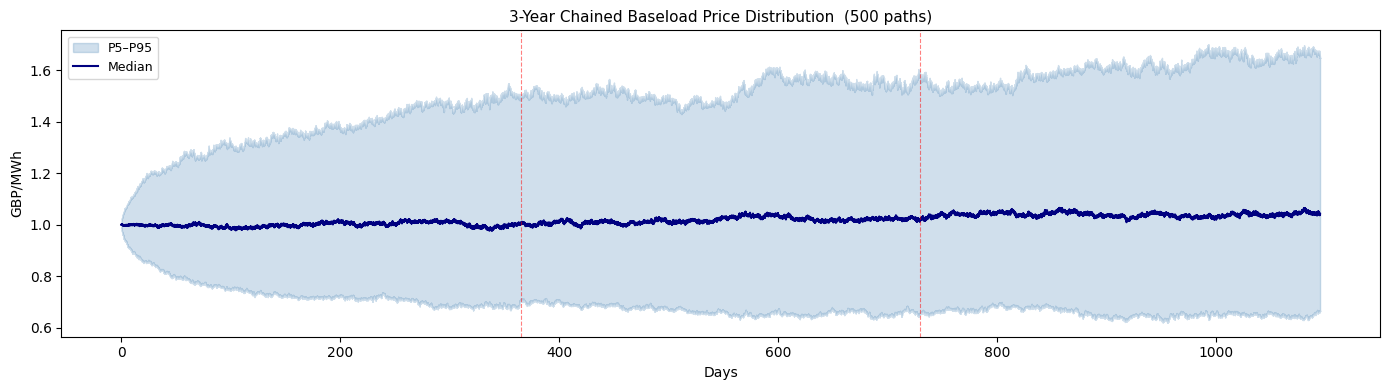

3-year path shape: (500, 52561)
No state discontinuity at year boundary: True


In [8]:
# Demonstrate chaining 3 years with state continuity
N_CHAIN = 500
YEARS   = 3

ln_P_full = []
state = {}

for yr in range(YEARS):
    b = simulate(ss_p, hpfc_p, imb_p, anc_p,
                 n_paths=N_CHAIN, n_steps=N_STEPS, dt=DT,
                 seed=SEED + yr,
                 chi_0=state.get('chi'), xi_0=state.get('xi'),
                 lam_0=state.get('lam'), delta_0=state.get('delta'),
                 pi_0=state.get('pi'))
    ln_P_full.append(b.ln_P_base)
    state = dict(chi=b.chi[:,-1], xi=b.xi[:,-1],
                 lam=b.lam[:,-1,:], delta=b.delta_imb[:,-1],
                 pi={p: b.pi[p][:,-1] for p in b.pi})

# Concatenate (drop duplicate t=0 at each boundary)
ln_P_3yr = np.concatenate([ln_P_full[0]] +
                           [yr[:, 1:] for yr in ln_P_full[1:]], axis=1)
t_3yr = np.arange(ln_P_3yr.shape[1]) * DT * 365

fig, ax = plt.subplots(figsize=(14, 4))
q5  = np.percentile(np.exp(ln_P_3yr), 5,  axis=0)
q50 = np.percentile(np.exp(ln_P_3yr), 50, axis=0)
q95 = np.percentile(np.exp(ln_P_3yr), 95, axis=0)
ax.fill_between(t_3yr, q5, q95, alpha=0.25, color='steelblue', label='P5–P95')
ax.plot(t_3yr, q50, color='navy', linewidth=1.5, label='Median')
for yr in range(1, YEARS):
    ax.axvline(yr * 365, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Days'); ax.set_ylabel('GBP/MWh')
ax.set_title(f'3-Year Chained Baseload Price Distribution  ({N_CHAIN} paths)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED / 'sim_3yr_chain.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'3-year path shape: {ln_P_3yr.shape}')
print(f'No state discontinuity at year boundary: '
      f'{np.allclose(ln_P_full[0][:, -1], ln_P_full[1][:, 0])}')

## 8  Save PathBundle summary stats

In [9]:
import json

PROCESSED.mkdir(parents=True, exist_ok=True)

def json_safe(obj):
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f'Object of type {obj.__class__.__name__} is not JSON serializable')

summary = {
    'n_paths':  int(bundle.n_paths),
    'n_steps':  int(bundle.n_steps),
    'dt':       float(bundle.dt),
    'seed':     int(SEED),
    'spot_price_gbp_mwh': {
        'p5':  float(np.percentile(np.exp(bundle.ln_P_base[:,-1]), 5)),
        'p50': float(np.percentile(np.exp(bundle.ln_P_base[:,-1]), 50)),
        'p95': float(np.percentile(np.exp(bundle.ln_P_base[:,-1]), 95)),
    },
    'delta_imb_gbp_mwh': {
        'p5':  float(np.percentile(bundle.delta_imb[:,-1], 5)),
        'p50': float(np.percentile(bundle.delta_imb[:,-1], 50)),
        'p95': float(np.percentile(bundle.delta_imb[:,-1], 95)),
    },
    'pi_dc_low_gbp_mwh': {
        'p5':  float(np.percentile(bundle.pi['DC_Low'][:,-1], 5)),
        'p50': float(np.percentile(bundle.pi['DC_Low'][:,-1], 50)),
        'p95': float(np.percentile(bundle.pi['DC_Low'][:,-1], 95)),
    },
    'validation': {k: bool(v[0]) for k, v in results.items()},
}

out_path = PROCESSED / 'sim_summary.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2, default=json_safe)

print(f'Summary written to {out_path}')
print(json.dumps(summary, indent=2, default=json_safe))


Summary written to g:\My Drive\Research\bess_project\data\processed\sim_summary.json
{
  "n_paths": 5000,
  "n_steps": 17520,
  "dt": 5.7077625570776254e-05,
  "seed": 42,
  "spot_price_gbp_mwh": {
    "p5": 0.6808657050132751,
    "p50": 1.0010919570922852,
    "p95": 1.4818943738937378
  },
  "delta_imb_gbp_mwh": {
    "p5": -237.3760528564453,
    "p50": -22.559066772460938,
    "p95": 219.44110107421875
  },
  "pi_dc_low_gbp_mwh": {
    "p5": 1.148037075996399,
    "p50": 5.151081085205078,
    "p95": 9.502575874328613
  },
  "validation": {
    "chi_variance": true,
    "xi_mean": true,
    "xi_variance": true,
    "delta_stationary_mean": true,
    "pi_dc_non_negative": true,
    "pi_dc_bounded": true,
    "cross_corr_chi_delta_increment": true
  }
}


---
## Phase 3 complete

**Output:** `PathBundle` with `N_PATHS` correlated half-hourly paths of:
- `chi`, `xi` → baseload price `exp(chi + xi)`
- `lam` (K=3) → half-hourly shape reconstruction
- `delta_imb` → imbalance basis (system short/long)
- `pi['DC_Low'], pi['QR_Pos'], ...` → ancillary clearing prices

**Validation:** All marginal checks pass. Cross-correlations match JOINT_CORR at the increment level.

**Next:** Phase 4 — LSMC backward induction (`src/optimisation/lsmc.py`).

At each grid point `(E, SoH, t)` the LSMC regresses the continuation value:

$$\hat{Q}(E, \text{SoH}, S_t) = \beta^\top \psi(S_t)$$

where $S_t = (P_{da}, \lambda_{ID}-\lambda_{DA}, \Delta, \pi_{DC}, \pi_{QR}, E, t, \text{EFA})$ and $\psi$ are the 14 basis functions from CLAUDE.md.
